<a href="https://colab.research.google.com/github/nittasamith1/Bank-Customer-Churn-Prediction-using-Random-Forest/blob/main/RandomForest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
data = pd.read_csv("/content/Churn_Modelling.csv")

In [13]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [14]:
data.shape

(10000, 14)

In [15]:
data.isnull().sum()

,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [17]:
data.duplicated().sum()

np.int64(0)

In [18]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [49]:
data = data.drop(columns=["RowNumber", "CustomerId", "Surname"])

In [50]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
data["Geography"] = encoder.fit_transform(data["Geography"])
data["Gender"] = encoder.fit_transform(data["Gender"])

In [21]:
data.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,0,0,42,2,0.00,1,1,1,101348.88,1
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1
3,699,0,0,39,1,0.00,2,0,0,93826.63,0
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0


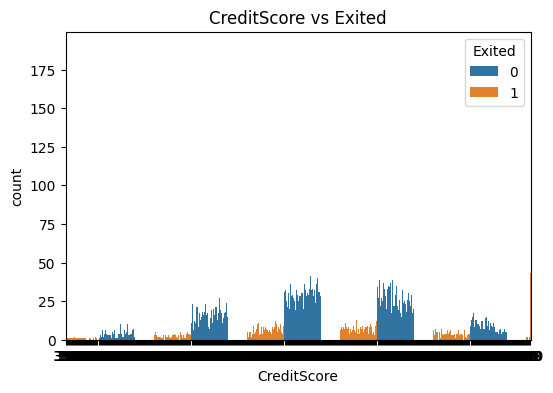

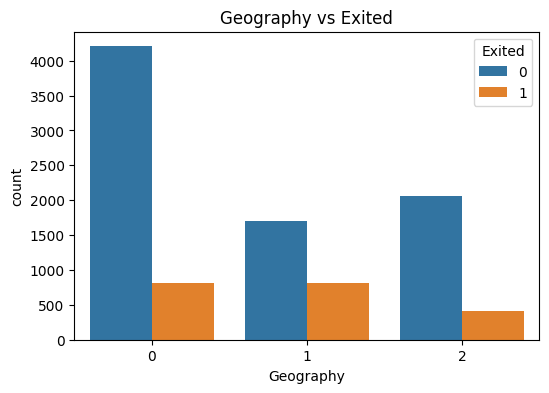

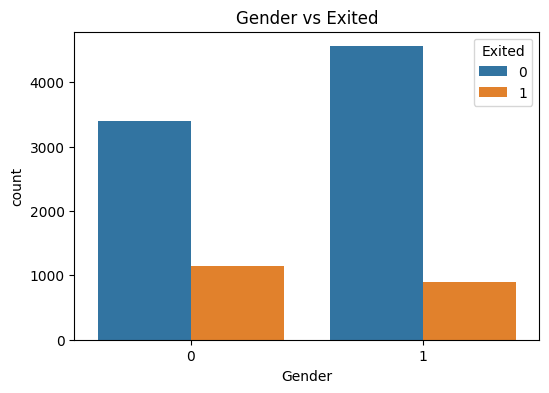

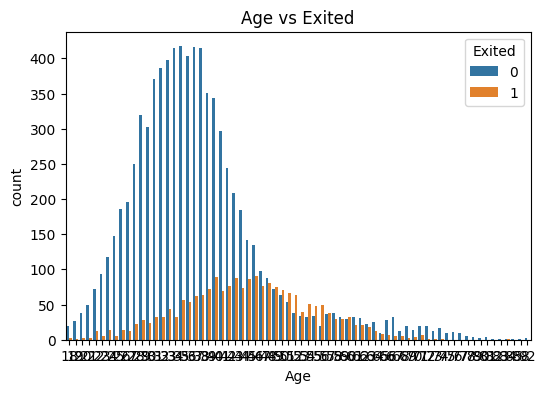

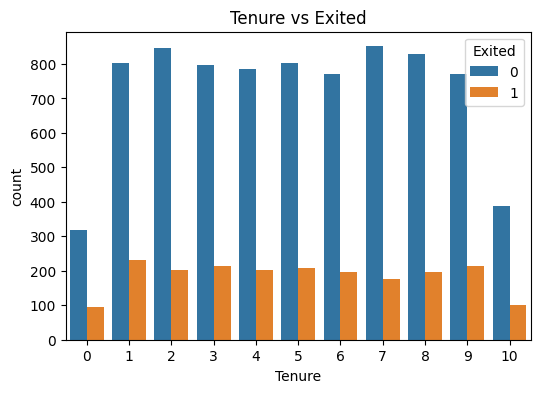

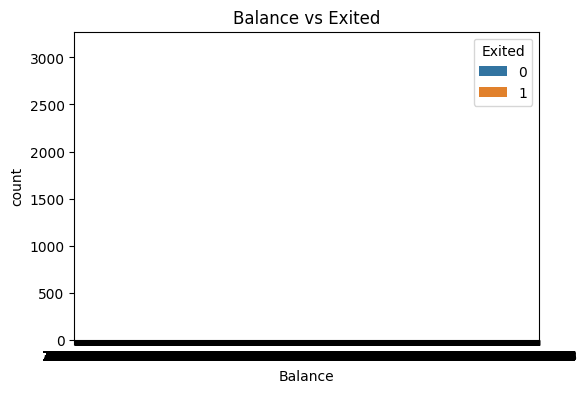

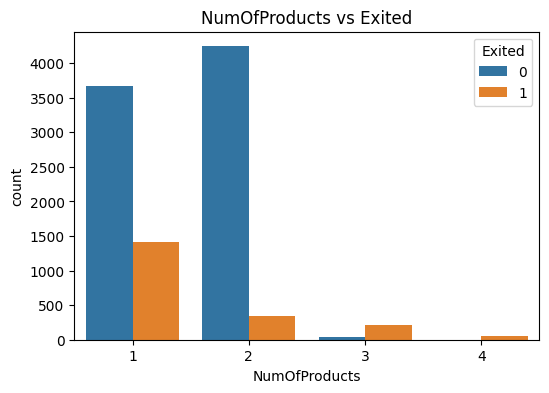

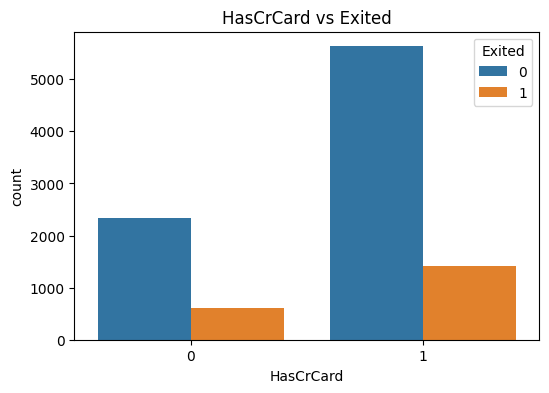

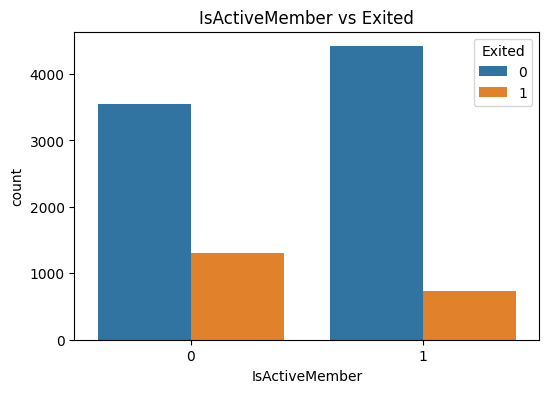

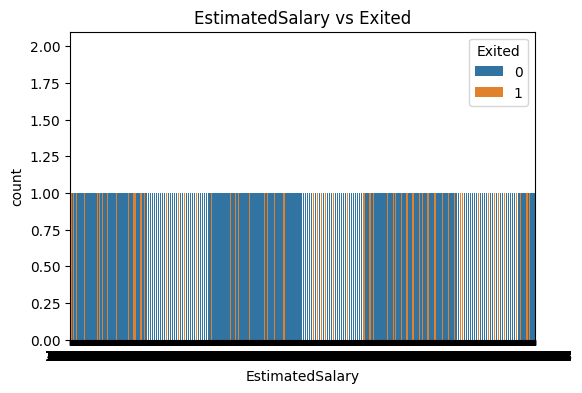

In [27]:
for col in data.drop(columns=['Exited']):
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue="Exited", data=data)
    plt.title(f"{col} vs Exited")
    plt.show()

<Axes: >

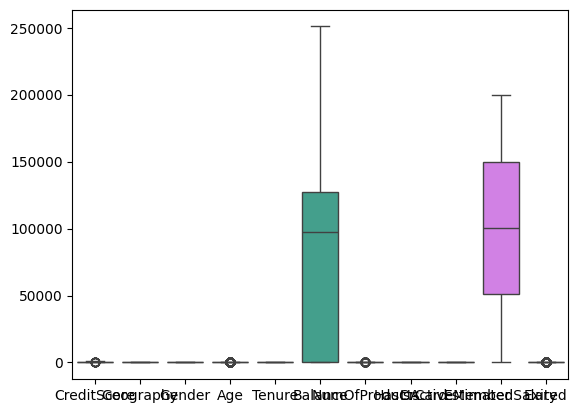

In [28]:
sns.boxplot(data)

In [58]:
data.drop(columns=["EstimatedSalary", "Balance"])

,CreditScore,Geography,Gender,Age,Tenure,NumOfProducts,HasCrCard,IsActiveMember,Exited
0,619,0,0,42,2,1,1,1,1
1,608,2,0,41,1,1,0,1,0
2,502,0,0,42,8,3,1,0,1
3,699,0,0,39,1,2,0,0,0
4,850,2,0,43,2,1,1,1,0
...,...,...,...,...,...,...,...,...,...
9995,771,0,1,39,5,2,1,0,0
9996,516,0,1,35,10,1,1,1,0
9997,709,0,0,36,7,1,0,1,1
9998,772,1,1,42,3,2,1,0,1


In [59]:
x = data.drop(columns=["Exited"])
y = data["Exited"]

In [60]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [61]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=10)
model.fit(x_train, y_train)

RandomForestClassifier(n_estimators=10)

In [62]:
y_pred = model.predict(x_test)

In [63]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.8515
[[1535   72]
 [ 225  168]]
              precision    recall  f1-score   support

           0       0.87      0.96      0.91      1607
           1       0.70      0.43      0.53       393

    accuracy                           0.85      2000
   macro avg       0.79      0.69      0.72      2000
weighted avg       0.84      0.85      0.84      2000



In [64]:
errorrate =[]

for i in range(1, 40):
    model = RandomForestClassifier(n_estimators=i)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    errorrate.append(np.mean(y_test != y_pred))

Text(0, 0.5, 'errorrate')

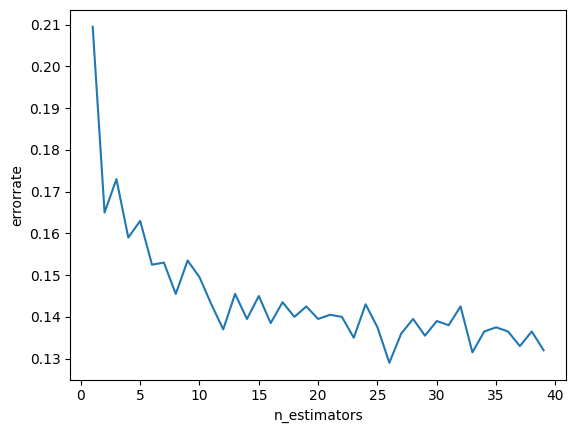

In [65]:
plt.plot(range(1, 40), errorrate)
plt.xlabel("n_estimators")
plt.ylabel("errorrate")

In [66]:
model = RandomForestClassifier(n_estimators=26)
model.fit(x_train, y_train)

RandomForestClassifier(n_estimators=26)

In [67]:
y_pred = model.predict(x_test)

In [68]:
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.867
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



<Axes: >

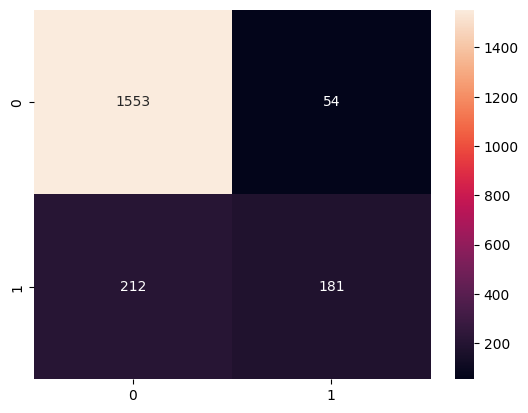

In [69]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")